In [1]:
using Pkg
Pkg.activate("$(ENV["DIVA_LIB"])")
include("$(ENV["DIVA_LIB"])/src/DIVACoast.jl")
using .DIVACoast
using DataFrames

  Activating project at `C:\Users\Lars\Work\Global_Climate_Forum\DIVA\DIVACoast`
┌ Warning: Replacing docs for `Main.DIVACoast.damage_bathtub_standard_ddf :: Union{Tuple{DT}, Tuple{Main.DIVACoast.HypsometricProfile{DT}, DT, DT, Array{DT}}} where DT<:Real` in module `Main.DIVACoast`
└ @ Base.Docs docs\Docs.jl:243


┌                                       ┐
│ DIVACoast.jl | © GLOBAL CLIMATE FORUM │
└                                       ┘


# Hypsometric Profiles
A hypsometric profile represents a cross-section of the coastal zone, mapping elevation to the cumulative exposure below that elevation. It is calculated by incrementally increasing the water level and accumulating the exposures and exposed area at each step. For further analysis on the `HypsometricPofile` exposure values are linear interpolated between the initial waterlevel increments. 

1. Load a `HypsometricProfile` in a collection

In this example we will provide you with a set of hypsometric profiles stored in a netCDF file. You can load the profiles using the `load_hsps_nc()` function. The function will return a `Dict()` mapping IDs of hypsometric profiles to the corresponding `HypsometricProfile` structure. Within DIVACoast we provide an additional structure to handle such a collection of hypsometric profiles, called `HypsometrictProfileCollection`. 

In [2]:
profiles = load_hsps_nc(Int32, Float32, "../testdata/UKIRL/nc/UKIRL_hspfs_floodplains.nc") |> HypsometricProfileCollection

┌ HypsometricProfileCollection
└ Number of HypsometricProfiles: 2733



As indicated by the output, our `HypsometricProfileCollection` contains 2733 `HypsometricProfiles`

2. Indexing a `HypsometricProfileCollection`

You can index the `HypsometricProfileCollection` using the ID assosciated with a `HypsometricProfile` or by a numeric index. Let's look at he `HypsometricProfile` 42: As you can see the plot shows how "far" a certain elevation reaches into the land, considering hydrological connectivity. In addition, the plot shows the __Low Elevation Coastal Zone__, a margin defined "area below 10m above mean Sea-Level"

Let's look at an individual Profile. The `HypsometricProfile` for the South of London has the Id "2474". You can Index the collection either by an integer to get the nth profile or by and key to get a profile with a specific Id. **Note: profiles[42] is not the same as profiles["42"]**

In [6]:
south_london = profiles["2474"]
south_london

┌ HypsometricProfile
├ Width: 78.30824 km
├ Elevation: -5.0 up to 20.0m at 251 increments
├ Cum. area (maximum): 710.52454km^2
└ Exposures:
  ├ population: 251 values from 0.0 to 3.5589345e6
  ├ assets: 251 values from 0.0 to 5.2497957e11

To further analyze the profile you can translate it to a `DataFrame`

In [7]:
DataFrame(south_london)

Row,elevation,cumulativeArea,width,population,assets
,Float32,Float32,Float32,Float32,Float32
1,-5.0,0.0,78.3082,0.0,0.0
2,-4.9,0.122944,78.3082,45.0435,6.72863e6
3,-4.8,0.12829,78.3082,45.0435,6.72863e6
4,-4.7,0.149668,78.3082,45.3815,6.7737e6
5,-4.6,0.149668,78.3082,45.3815,6.7737e6
6,-4.5,0.149668,78.3082,45.3815,6.7737e6
7,-4.4,0.149668,78.3082,45.3815,6.7737e6
8,-4.3,0.15501,78.3082,45.3815,6.7737e6
9,-4.2,0.15501,78.3082,45.3815,6.7737e6


... or plot it.

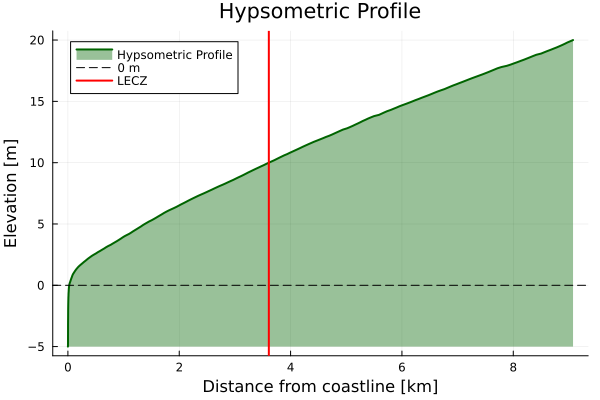

In [10]:
using Plots
plot(south_london)

In [18]:
dfp = DataFrame(profiles)
grouped = groupby(dfp, :ID)

Row,ID,elevation,cumulativeArea,width,population,assets
,String,Float32,Float32,Float32,Float32,Float32
1,2288,-5.0,0.0,1.29803,0.0,0.0
2,2288,-4.9,0.0,1.29803,0.0,0.0
3,2288,-4.8,0.0,1.29803,0.0,0.0
4,2288,-4.7,0.0,1.29803,0.0,0.0
5,2288,-4.6,0.0,1.29803,0.0,0.0
6,2288,-4.5,0.0,1.29803,0.0,0.0
7,2288,-4.4,0.0,1.29803,0.0,0.0
8,2288,-4.3,0.0,1.29803,0.0,0.0
9,2288,-4.2,0.0,1.29803,0.0,0.0
